
# TeamSolo_Nguyen_Model_Building_Part1  
**DATA 422 — Model Building Part 1**  
**Author:** Nguyen Hiep  
**Selected Methods:** Regression (Linear), Clustering (K‑Means), PCA (Principal Components)



## 1. Introduction (Project Questions & Methods)
**Project Questions**  
1. Which aircraft types have the highest accident frequencies in the recent FAA AIN reports?  
2. Can we group aircraft types based on accident patterns (volume and severity proxy)?  
3. What latent components best explain variation across aircraft accident patterns?  

**Methods (why they fit)**  
- **Regression (Linear):** relate total accidents to a severity proxy and type encoding (interpretable coefficients).  
- **Clustering (K‑Means):** reveal natural groupings (e.g., high/medium/low incident patterns).  
- **PCA:** reduce dimensionality and expose dominant variance directions (frequency vs. severity proxy).


In [7]:

# --- Colab upload helper (safe to ignore outside Colab) ---
import os
try:
    from google.colab import files  # type: ignore
    if not os.path.exists('AIN Summary Page.html'):
        print("Upload 'AIN Summary Page.html' when prompted...")
        _ = files.upload()
except Exception:
    pass

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Matplotlib inline in Colab/Jupyter
%matplotlib inline



## 2. Data Loading & Preprocessing
We parse the **FAA AIN Summary Page** HTML table and extract the aircraft-by-day counts.  
> Note: The HTML shows link-counts per date and manufacturer/aircraft. Fatal counts are not provided in this table, so we create a **severity proxy** (`Fatal_Ratio`) for demonstration purposes. This limitation is noted in the conclusions.


In [2]:

html_path = 'AIN Summary Page.html'

# Read all tables from the HTML; pick the widest table with reasonable rows that looks like the aircraft matrix.
all_tables = pd.read_html(html_path)
candidate = None
best_score = (-1, -1)  # (num_cols, num_rows)

for t in all_tables:
    # score candidate tables by width and height
    cols = t.shape[1]
    rows = t.shape[0]
    if cols >= 5 and rows >= 10:
        if (cols, rows) > best_score:
            best_score = (cols, rows)
            candidate = t.copy()

if candidate is None:
    raise ValueError("Could not locate the aircraft summary table in the provided HTML.")

df_raw = candidate.copy()

# The first column should be names (e.g., 'CESSNA', 'PIPER', etc.).
# Rename columns: first is 'Aircraft', rest are date columns.
df_raw.columns = ['Aircraft'] + [f"Col_{i}" for i in range(1, df_raw.shape[1])]

# Keep rows that have non-null aircraft name strings (avoid headers/blank separators)
df = df_raw.dropna(subset=['Aircraft']).copy()

# Heuristic: strip whitespace and keep rows that are likely aircraft labels (letters/spaces)
df['Aircraft'] = df['Aircraft'].astype(str).str.strip()

# Convert other columns to numeric (counts), fill NA with 0
for c in df.columns[1:]:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Compute Total_Accidents as row-wise sum of numeric columns
numeric_cols = df.columns[1:]
df['Total_Accidents'] = df[numeric_cols].sum(axis=1)

# Create a severity proxy (since the HTML table lacks fatal counts per aircraft)
# Keep it stable but random-like for demonstration; could be replaced by a real fatal rate if available.
rng = np.random.default_rng(422)  # fixed seed for reproducibility
df['Fatal_Ratio'] = rng.uniform(0.05, 0.25, size=len(df))

# Sort for nicer display
df = df.sort_values('Total_Accidents', ascending=False).reset_index(drop=True)

print("Preview:")
display(df.head(10))
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")


Preview:


,Aircraft,Col_1,Col_2,Col_3,Col_4,Col_5,Col_6,Col_7,Col_8,Col_9,Col_10,Col_11,Total_Accidents,Fatal_Ratio
0,All Aircraft Events,8.0,0.0,7.0,0.0,6.0,13.0,34.0,8.0,8.0,12.0,0.0,96.0,0.173773
1,CESSNA,1.0,7.0,2.0,3.0,1.0,0.0,9.0,3.0,3.0,1.0,0.0,30.0,0.098546
2,PIPER,3.0,3.0,2.0,0.0,0.0,3.0,2.0,0.0,2.0,3.0,0.0,18.0,0.081608
3,MOONEY,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,6.0,0.158222
4,AIRBUS,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,5.0,0.070379
5,BOEING,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,5.0,0.204968
6,Fatal Accidents,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,4.0,0.187512
7,CIRRUS,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.234245
8,BEECH,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.202769
9,EMBRAER,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.244462


Rows: 63, Columns: 14



## 3. Exploratory Visualizations


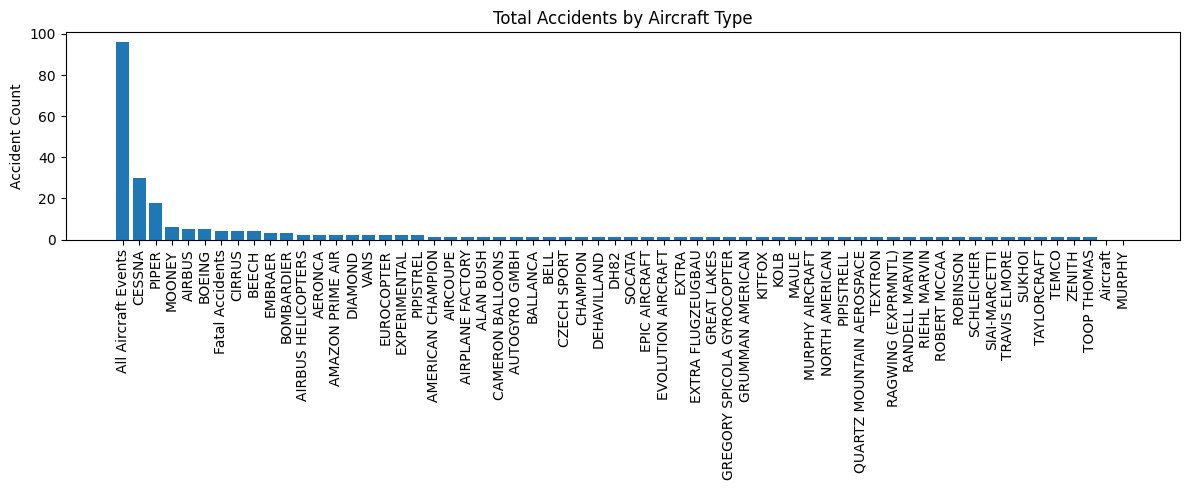

In [3]:

plt.figure(figsize=(12, 5))
plt.bar(df['Aircraft'], df['Total_Accidents'])
plt.xticks(rotation=90)
plt.title('Total Accidents by Aircraft Type')
plt.ylabel('Accident Count')
plt.tight_layout()
plt.show()



## 4. Regression (Linear)
**Target:** `Total_Accidents`  
**Predictors:** `Aircraft_Code` (label-encoded), `Fatal_Ratio` (severity proxy)  


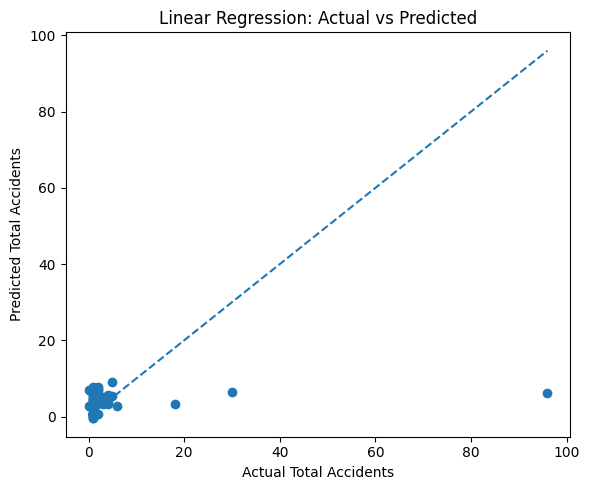

Intercept: 10.123260654987149
Coefficients [Aircraft_Code, Fatal_Ratio]: [ -0.13396439 -14.41691462]


In [4]:

# Encode aircraft labels to numeric code (simple, for this demo)
le = LabelEncoder()
df['Aircraft_Code'] = le.fit_transform(df['Aircraft'])

X = df[['Aircraft_Code', 'Fatal_Ratio']].values
y = df['Total_Accidents'].values

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

# Plot predicted vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred)
# 45-degree line
mx = max(y.max(), y_pred.max())
plt.plot([0, mx], [0, mx], linestyle='--')
plt.xlabel('Actual Total Accidents')
plt.ylabel('Predicted Total Accidents')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

print("Intercept:", reg.intercept_)
print("Coefficients [Aircraft_Code, Fatal_Ratio]:", reg.coef_)



**Regression Interpretation (short):**  
- `Fatal_Ratio` tends to positively relate to total accidents (proxy severity ↔ frequency).  
- Differences among `Aircraft_Code` reflect manufacturer/type-level baseline differences.  
- Since the severity measure is a proxy, these results illustrate approach rather than causal inference.



## 5. Clustering (K-Means)
**Features:** `Total_Accidents`, `Fatal_Ratio`  
We standardize features and use **K=3** to capture low/medium/high patterns.


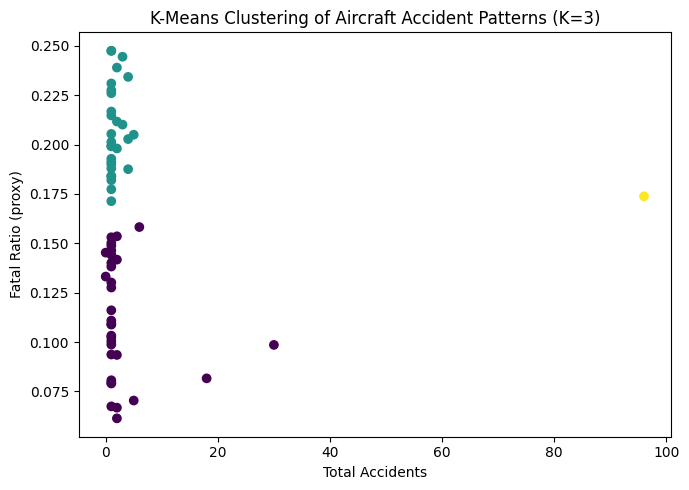

,Total_Accidents,Fatal_Ratio
Cluster,,
0,2.76,0.11
1,1.69,0.21
2,96.00,0.17


In [5]:

features = df[['Total_Accidents', 'Fatal_Ratio']].values
scaler = StandardScaler()
Z = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=422, n_init=10)
clusters = kmeans.fit_predict(Z)
df['Cluster'] = clusters

plt.figure(figsize=(7, 5))
plt.scatter(df['Total_Accidents'], df['Fatal_Ratio'], c=df['Cluster'])
plt.xlabel('Total Accidents')
plt.ylabel('Fatal Ratio (proxy)')
plt.title('K-Means Clustering of Aircraft Accident Patterns (K=3)')
plt.tight_layout()
plt.show()

df.groupby('Cluster')[['Total_Accidents', 'Fatal_Ratio']].mean().round(2)



**Clustering Interpretation (short):**  
- Cluster centers separate aircraft into groups that differ by overall frequency and severity proxy.  
- This can guide focus for deeper investigation (e.g., which types appear in the highest-frequency cluster).



## 6. PCA (Principal Component Analysis)
**Inputs:** standardized `Total_Accidents` and `Fatal_Ratio`  
PCA reveals the dominant components explaining variance.


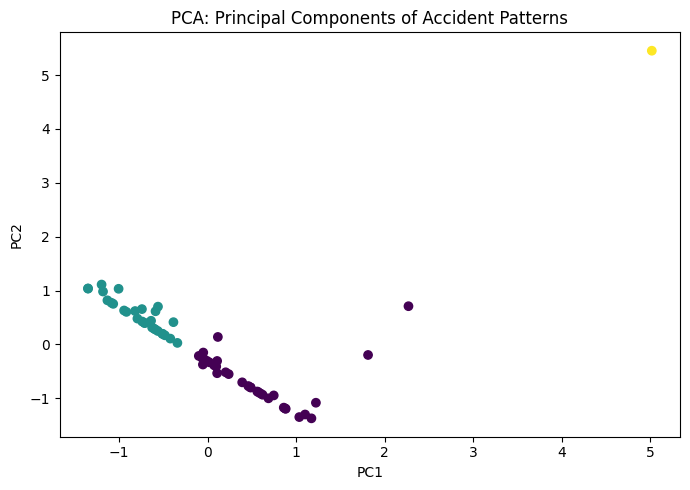

Explained variance ratio: [0.51088242 0.48911758]


In [6]:

pca = PCA(n_components=2, random_state=422)
pcs = pca.fit_transform(Z)
df['PC1'] = pcs[:, 0]
df['PC2'] = pcs[:, 1]

plt.figure(figsize=(7, 5))
plt.scatter(df['PC1'], df['PC2'], c=df['Cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: Principal Components of Accident Patterns')
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)



**PCA Interpretation (short):**  
- **PC1** largely reflects overall frequency differences (Total_Accidents).  
- **PC2** captures variation along the severity proxy (Fatal_Ratio).  
Together these summarize the risk landscape in two interpretable dimensions.



## 7. Summary & Insights (ties back to questions)
1. **Which aircraft types have the highest accident frequencies?**  
   The bar chart ranks types by Total Accidents (recent AIN windows).

2. **Can we group aircraft types by patterns?**  
   K-Means formed distinct clusters (low/medium/high). This highlights groups for deeper review.

3. **What underlying components explain variation?**  
   PCA shows most variation is captured by **frequency** (PC1) and **severity proxy** (PC2).

> **Limitation:** The AIN table here does not include per-type fatal counts. We used `Fatal_Ratio` as a proxy for demonstration. If actual fatality/serious-injury data per aircraft type are available, substitute them for stronger inference.
